# Лабораторная работа 1

Студент: Захаров Никита Константинович
Группа: 6403-010302D


1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Вариант 2: задания 1 и 2 на наборе данных MNIST

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

Вариант 4: задания 1 и 3 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [2]:
import os
import shutil
import tarfile
import tempfile
import urllib.request
from scripts.data_utils import load_CIFAR10

cifar_root = os.path.join(tempfile.gettempdir(), 'cifar-10-batches-py')
archive = os.path.join(tempfile.gettempdir(), 'cifar-10-python-openai.tar.gz')
required_file = os.path.join(cifar_root, 'data_batch_1')
if not os.path.isfile(required_file):
    if os.path.isdir(cifar_root):
        shutil.rmtree(cifar_root)
    if os.path.isfile(archive):
        try:
            with tarfile.open(archive, 'r:gz') as tar:
                tar.getmembers()
        except Exception:
            os.remove(archive)
    if not os.path.isfile(archive):
        urllib.request.urlretrieve('https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz', archive)
    with tarfile.open(archive, 'r:gz') as tar:
        tar.extractall(tempfile.gettempdir())

X_train, y_train, X_test, y_test = load_CIFAR10(cifar_root)


print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)


/home/ZakharovNK/project/AIT_Course_SamU_2026/lab_1-2/scripts/data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



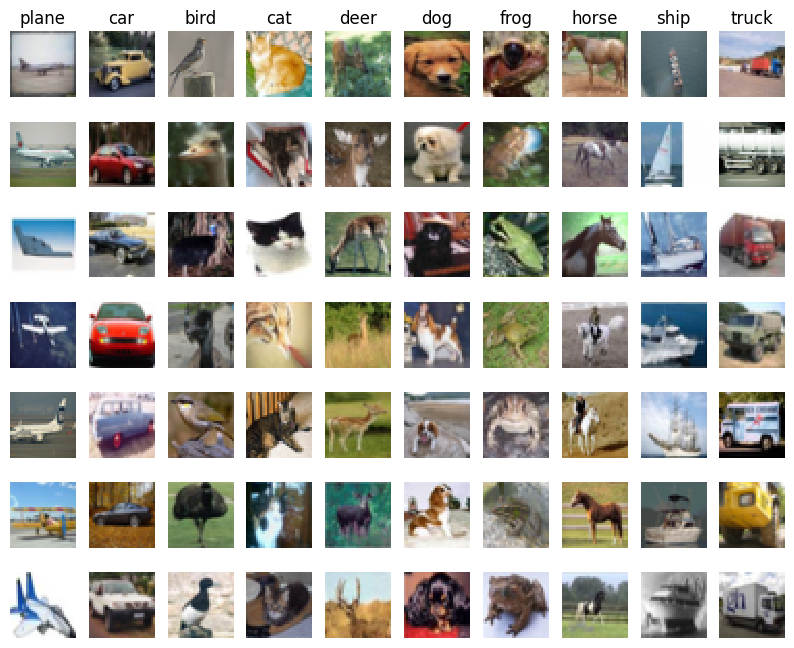

In [3]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()


1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [4]:
num_training = 2000
num_test = 500
mask = np.random.choice(X_train.shape[0], num_training, replace=False)
X_train = X_train[mask]
y_train = y_train[mask]
mask = np.random.choice(X_test.shape[0], num_test, replace=False)
X_test = X_test[mask]
y_test = y_test[mask]

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)


Training data shape:  (2000, 3072)
Training labels shape:  (2000,)
Test data shape:  (500, 3072)
Test labels shape:  (500,)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [5]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [6]:
y_test_pred = classifier.predict(X_test, k=1)


1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


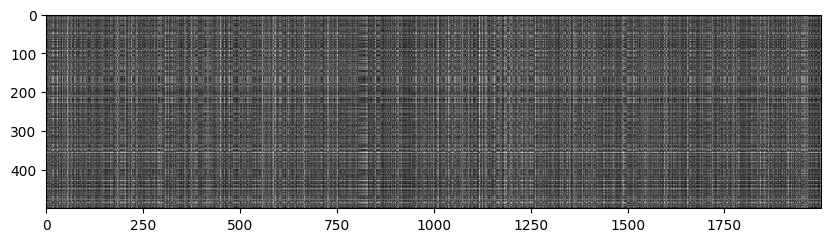

In [7]:
dists = classifier.compute_distances_no_loops(X_test)
plt.imshow(dists, interpolation='none')
plt.show()



1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [8]:
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))


Got 127 / 500 correct => accuracy: 0.254000


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

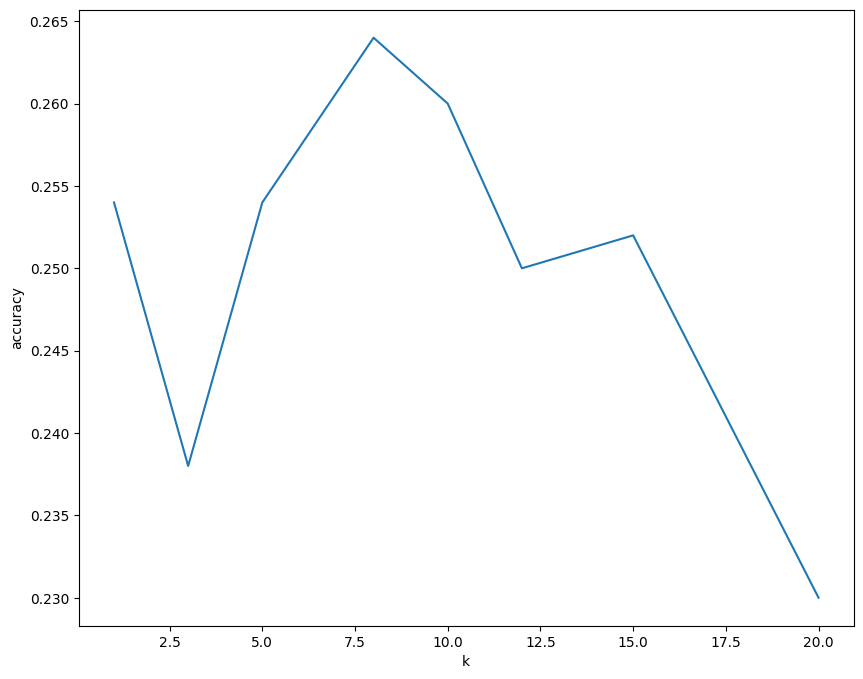

In [9]:
k_choices = [1, 3, 5, 8, 10, 12, 15, 20]
accuracies = []
for k in k_choices:
    y_test_pred = classifier.predict(X_test, k=k)
    accuracies.append(np.mean(y_test_pred == y_test))

plt.plot(k_choices, accuracies)
plt.xlabel('k')
plt.ylabel('accuracy')
plt.show()


1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


k = 1, accuracy = 0.230000
k = 1, accuracy = 0.225000
k = 1, accuracy = 0.192500
k = 1, accuracy = 0.262500
k = 1, accuracy = 0.242500
k = 3, accuracy = 0.217500
k = 3, accuracy = 0.207500
k = 3, accuracy = 0.232500
k = 3, accuracy = 0.227500
k = 3, accuracy = 0.207500
k = 5, accuracy = 0.235000
k = 5, accuracy = 0.215000
k = 5, accuracy = 0.240000
k = 5, accuracy = 0.250000
k = 5, accuracy = 0.225000
k = 8, accuracy = 0.242500
k = 8, accuracy = 0.227500
k = 8, accuracy = 0.245000
k = 8, accuracy = 0.262500
k = 8, accuracy = 0.217500
k = 10, accuracy = 0.247500
k = 10, accuracy = 0.227500
k = 10, accuracy = 0.242500
k = 10, accuracy = 0.267500
k = 10, accuracy = 0.232500
k = 12, accuracy = 0.255000
k = 12, accuracy = 0.217500
k = 12, accuracy = 0.257500
k = 12, accuracy = 0.240000
k = 12, accuracy = 0.222500
k = 15, accuracy = 0.262500
k = 15, accuracy = 0.232500
k = 15, accuracy = 0.255000
k = 15, accuracy = 0.237500
k = 15, accuracy = 0.252500
k = 20, accuracy = 0.265000
k = 20, accu

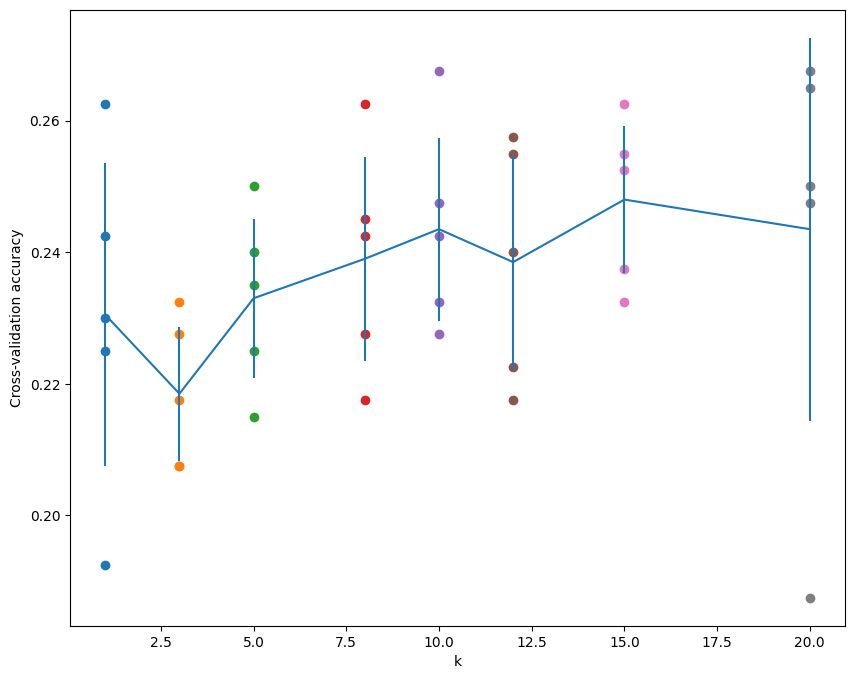

Best k: 15


In [10]:
num_folds = 5
k_choices = [1, 3, 5, 8, 10, 12, 15, 20]
X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)
k_to_accuracies = {}

for k in k_choices:
    k_to_accuracies[k] = []
    for fold in range(num_folds):
        X_train_cv = np.concatenate([X_train_folds[i] for i in range(num_folds) if i != fold])
        y_train_cv = np.concatenate([y_train_folds[i] for i in range(num_folds) if i != fold])
        X_val_cv = X_train_folds[fold]
        y_val_cv = y_train_folds[fold]
        classifier = KNearestNeighbor()
        classifier.train(X_train_cv, y_train_cv)
        y_val_pred = classifier.predict(X_val_cv, k=k)
        k_to_accuracies[k].append(np.mean(y_val_pred == y_val_cv))

for k in sorted(k_to_accuracies):
    for accuracy in k_to_accuracies[k]:
        print('k = %d, accuracy = %f' % (k, accuracy))

best_k = max(k_to_accuracies, key=lambda k: np.mean(k_to_accuracies[k]))
for k in k_choices:
    plt.scatter([k] * len(k_to_accuracies[k]), k_to_accuracies[k])
means = np.array([np.mean(k_to_accuracies[k]) for k in k_choices])
stds = np.array([np.std(k_to_accuracies[k]) for k in k_choices])
plt.errorbar(k_choices, means, yerr=stds)
plt.xlabel('k')
plt.ylabel('Cross-validation accuracy')
plt.show()
print('Best k:', best_k)



1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [11]:
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k)
num_correct = np.sum(y_test_pred == y_test)
accuracy = float(num_correct) / num_test
print('Got %d / %d correct => accuracy: %f' % (num_correct, num_test, accuracy))


Got 126 / 500 correct => accuracy: 0.252000


1.11 Сделайте выводы по результатам 1 части задания.

kNN на CIFAR-10 работает стабильно, но быстро упирается в качество и вычислительную стоимость. Подбор k через кросс-валидацию улучшает accuracy, однако метод остаётся медленным на больших выборках и плохо масштабируется по сравнению с обучаемыми линейными моделями.


## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [12]:
import os
import shutil
import tarfile
import tempfile
import urllib.request
from scripts.data_utils import load_CIFAR10

cifar_root = os.path.join(tempfile.gettempdir(), 'cifar-10-batches-py')
archive = os.path.join(tempfile.gettempdir(), 'cifar-10-python-openai.tar.gz')
required_file = os.path.join(cifar_root, 'data_batch_1')
if not os.path.isfile(required_file):
    if os.path.isdir(cifar_root):
        shutil.rmtree(cifar_root)
    if os.path.isfile(archive):
        try:
            with tarfile.open(archive, 'r:gz') as tar:
                tar.getmembers()
        except Exception:
            os.remove(archive)
    if not os.path.isfile(archive):
        urllib.request.urlretrieve('https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz', archive)
    with tarfile.open(archive, 'r:gz') as tar:
        tar.extractall(tempfile.gettempdir())

X_train, y_train, X_test, y_test = load_CIFAR10(cifar_root)


num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
X_dev = X_dev.reshape(X_dev.shape[0], -1)

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('Dev data shape: ', X_dev.shape)
print('Dev labels shape: ', y_dev.shape)


Train data shape:  (49000, 3072)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3072)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3072)
Test labels shape:  (1000,)
Dev data shape:  (500, 3072)
Dev labels shape:  (500,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


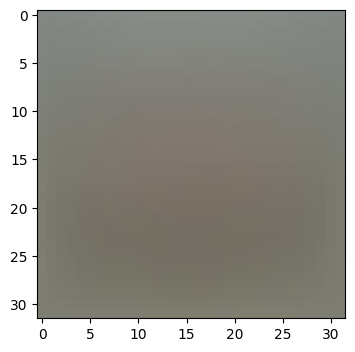

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [13]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) 
plt.show()

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [14]:

from scripts.classifiers.linear_svm import svm_loss_naive
import time


W = np.random.randn(3073, 10) * 0.0001 

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

loss: 8.805545



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [15]:

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: -5.816349 analytic: -5.816349, relative error: 1.099070e-11
numerical: 33.070010 analytic: 33.070010, relative error: 9.796978e-12
numerical: 27.210459 analytic: 27.210459, relative error: 9.994630e-12
numerical: -7.301817 analytic: -7.301817, relative error: 9.749286e-13
numerical: -16.341230 analytic: -16.341230, relative error: 6.766497e-12
numerical: -1.332586 analytic: -1.332586, relative error: 2.808388e-11
numerical: 10.363886 analytic: 10.363886, relative error: 2.837832e-11
numerical: -2.774388 analytic: -2.774388, relative error: 2.145538e-10
numerical: 3.197115 analytic: 3.197115, relative error: 3.796312e-11
numerical: 12.122511 analytic: 12.186678, relative error: 2.639610e-03
numerical: 20.379214 analytic: 20.379214, relative error: 5.206547e-12
numerical: 13.652366 analytic: 13.652366, relative error: 2.551402e-11
numerical: 15.538248 analytic: 15.538248, relative error: 1.288959e-11
numerical: 17.175217 analytic: 17.175217, relative error: 9.774545e-12
numeri

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [16]:
from scripts.classifiers.linear_svm import svm_loss_naive, svm_loss_vectorized
import time

tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)


Naive loss and gradient: computed in 0.027583s
Vectorized loss and gradient: computed in 0.006258s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [17]:
from scripts.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 798.601000
iteration 100 / 1500: loss 290.098987
iteration 200 / 1500: loss 108.934445
iteration 300 / 1500: loss 42.170031
iteration 400 / 1500: loss 19.264822
iteration 500 / 1500: loss 10.258530
iteration 600 / 1500: loss 6.974295
iteration 700 / 1500: loss 6.021342
iteration 800 / 1500: loss 5.485129
iteration 900 / 1500: loss 5.580282
iteration 1000 / 1500: loss 5.122078
iteration 1100 / 1500: loss 4.611213
iteration 1200 / 1500: loss 5.614167
iteration 1300 / 1500: loss 5.366284
iteration 1400 / 1500: loss 5.121414
That took 1.577285s


In [18]:
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.370143
validation accuracy: 0.373000


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [19]:
learning_rates = [1e-7, 2e-7]
regularization_strengths = [2.5e4, 5e4]
results = {}
best_val = -1
best_svm = None

for learning_rate in learning_rates:
    for reg in regularization_strengths:
        svm = LinearSVM()
        svm.train(X_train, y_train, learning_rate=learning_rate, reg=reg, num_iters=1000, verbose=False)
        train_accuracy = np.mean(y_train == svm.predict(X_train))
        val_accuracy = np.mean(y_val == svm.predict(X_val))
        results[(learning_rate, reg)] = (train_accuracy, val_accuracy)
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_svm = svm

for learning_rate, reg in sorted(results):
    train_accuracy, val_accuracy = results[(learning_rate, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (learning_rate, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)
y_test_pred = best_svm.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('linear SVM on raw pixels final test set accuracy: %f' % test_accuracy)


lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.364306 val accuracy: 0.362000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.355633 val accuracy: 0.359000
lr 2.000000e-07 reg 2.500000e+04 train accuracy: 0.353143 val accuracy: 0.360000
lr 2.000000e-07 reg 5.000000e+04 train accuracy: 0.335796 val accuracy: 0.338000
best validation accuracy achieved during cross-validation: 0.362000
linear SVM on raw pixels final test set accuracy: 0.365000


2.9 Сделайте выводы по второй части задания

## 3.  Построение softmax-классификатора

3.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [20]:
import os
import shutil
import tarfile
import tempfile
import urllib.request
from scripts.data_utils import load_CIFAR10

cifar_root = os.path.join(tempfile.gettempdir(), 'cifar-10-batches-py')
archive = os.path.join(tempfile.gettempdir(), 'cifar-10-python-openai.tar.gz')
required_file = os.path.join(cifar_root, 'data_batch_1')
if not os.path.isfile(required_file):
    if os.path.isdir(cifar_root):
        shutil.rmtree(cifar_root)
    if os.path.isfile(archive):
        try:
            with tarfile.open(archive, 'r:gz') as tar:
                tar.getmembers()
        except Exception:
            os.remove(archive)
    if not os.path.isfile(archive):
        urllib.request.urlretrieve('https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz', archive)
    with tarfile.open(archive, 'r:gz') as tar:
        tar.extractall(tempfile.gettempdir())

X_train, y_train, X_test, y_test = load_CIFAR10(cifar_root)


num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
X_dev = X_dev.reshape(X_dev.shape[0], -1)

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('Dev data shape: ', X_dev.shape)
print('Dev labels shape: ', y_dev.shape)


Train data shape:  (49000, 3072)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3072)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3072)
Test labels shape:  (1000,)
Dev data shape:  (500, 3072)
Dev labels shape:  (500,)


3.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

3.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву данных и заполните ее единицами.

[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


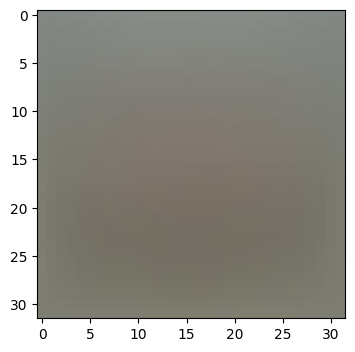

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [21]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image[:3072].reshape((32,32,3)).astype('uint8')) 
plt.show()

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)


3.4 Реализуйте функции в classifiers/softmax.py




In [22]:
from scripts.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.357801
sanity check: 2.302585


3.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [23]:
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)


from scripts.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)


loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: 2.950589 analytic: 2.950589, relative error: 1.139958e-08
numerical: 0.589540 analytic: 0.589540, relative error: 8.654283e-08
numerical: 2.545522 analytic: 2.545522, relative error: 5.114942e-09
numerical: -0.483200 analytic: -0.483200, relative error: 1.905445e-08
numerical: 1.245777 analytic: 1.245777, relative error: 5.758293e-09
numerical: -0.504670 analytic: -0.504671, relative error: 7.276466e-08
numerical: -0.458986 analytic: -0.458986, relative error: 4.621025e-09
numerical: 0.131060 analytic: 0.131060, relative error: 1.068265e-07
numerical: 0.415256 analytic: 0.415256, relative error: 1.807461e-08
numerical: 1.526582 analytic: 1.526582, relative error: 5.171227e-09
numerical: -0.336481 analytic: -0.336481, relative error: 9.132521e-08
numerical: -0.670609 analytic: -0.670610, relative error: 4.846191e-08
numerical: -3.909605 analytic: -3.909605, relative error: 1.339180e-08
numerical: 2.164677 analytic: 2.164677, relative error: 2.563130e-08
numerical: -3.174657 a

3.6 Сравните softmax_loss_naive и softmax_loss_vectorized реализации

In [24]:
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from scripts.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))


grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.357801e+00 computed in 0.031043s
vectorized loss: 2.357801e+00 computed in 0.017814s
Loss difference: 0.000000
Gradient difference: 0.000000


3.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.

3.9 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [25]:
from scripts.classifiers import Softmax

learning_rates = [1e-7, 5e-7]
regularization_strengths = [1e4, 5e4]
results = {}
best_val = -1
best_softmax = None

for learning_rate in learning_rates:
    for reg in regularization_strengths:
        softmax = Softmax()
        softmax.train(X_train, y_train, learning_rate=learning_rate, reg=reg, num_iters=1000, verbose=False)
        train_accuracy = np.mean(y_train == softmax.predict(X_train))
        val_accuracy = np.mean(y_val == softmax.predict(X_val))
        results[(learning_rate, reg)] = (train_accuracy, val_accuracy)
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_softmax = softmax

for learning_rate, reg in sorted(results):
    train_accuracy, val_accuracy = results[(learning_rate, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (learning_rate, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('softmax on raw pixels final test set accuracy: %f' % test_accuracy)


lr 1.000000e-07 reg 1.000000e+04 train accuracy: 0.333163 val accuracy: 0.339000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.308184 val accuracy: 0.323000
lr 5.000000e-07 reg 1.000000e+04 train accuracy: 0.352102 val accuracy: 0.368000
lr 5.000000e-07 reg 5.000000e+04 train accuracy: 0.303245 val accuracy: 0.321000
best validation accuracy achieved during cross-validation: 0.368000
softmax on raw pixels final test set accuracy: 0.360000


3.10 Сделайте выводы по третьей части задания

Softmax-классификатор на CIFAR-10 даёт более устойчивое и обычно более качественное решение, чем kNN на сырых пикселях. Кросс-валидация по скорости обучения и регуляризации заметно влияет на итоговую accuracy, а регуляризация помогает лучше обобщать на валидации и тесте.
